# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data
The data-cleaning steps below prepare the COMPAS variables used in this audit workflow, including criminal history, demographics, score information, and the recidivism outcome used for the downstream analysis.

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [ ]:
# Load Dataset

# Load the COMPAS dataset used in the original R script
# Using raw GitHub URL to ensure reproducibility

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape

(7214, 53)

In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select Relevant Variables
selected_cols = [
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]

df = raw_data[selected_cols].copy()

# Data Filtering
df = df[
    df["days_b_screening_arrest"].between(-30, 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

# Data Type Conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

categorical_cols = [col for col in df.columns if col not in numeric_vars + datetime_vars]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# Create derived categorical variables
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = df["age_cat"].astype("category")
df["race_factor"] = df["race"].astype("category")
df["gender_factor"] = df["sex"].astype("category")
df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = df["score_factor"].astype("category")

df.shape[0]

6172

In [ ]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

The dataset used here is a cleaned version of COMPAS data prepared in advance. The focus of this notebook is on how the model behaves after it is trained.

The following sections apply a structured audit to examine whether the model remains stable, interpretable, and reasonable beyond standard test-set evaluation.

## Base Model Used for This Audit

The primary audit is conducted on a Logistic Regression pipeline because it is the interpretable baseline, and a Gradient-Boosted Tree is fit alongside it as a higher-capacity comparison model.


In [ ]:
from IPython.display import display
from scipy.stats import ks_2samp
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.metrics.pairwise import pairwise_distances, rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

EPSILON = 1e-6
RANDOM_STATE = 42
GROUP_MIN_SUPPORT = 30

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", make_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
    )

def clip_probs(probs, epsilon=EPSILON):
    arr = np.asarray(probs, dtype=float)
    return np.clip(arr, epsilon, 1 - epsilon)

def predict_probabilities(estimator, X):
    probs = estimator.predict_proba(X)
    return probs[:, 1] if np.ndim(probs) > 1 else probs

target_col = "two_year_recid"
feature_cols = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "c_charge_degree",
    "race",
    "age_cat",
    "sex",
]
feature_cols = [col for col in feature_cols if col in df.columns]
numeric_features = ["age", "priors_count", "days_b_screening_arrest"]
categorical_features = ["c_charge_degree", "race", "age_cat", "sex"]

X = df[feature_cols].copy()
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

lr_pipeline = Pipeline(
    [
        ("preprocessor", make_preprocessor()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)
gbt_pipeline = Pipeline(
    [
        ("preprocessor", make_preprocessor()),
        ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)),
    ]
)

model_registry = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for estimator in model_registry.values():
    estimator.fit(X_train, y_train)

def base_model_metric_row(model_name, estimator):
    train_proba = clip_probs(predict_probabilities(estimator, X_train))
    test_proba = clip_probs(predict_probabilities(estimator, X_test))
    return {
        "model_name": model_name,
        "train_auc": roc_auc_score(y_train, train_proba),
        "test_auc": roc_auc_score(y_test, test_proba),
        "train_accuracy": accuracy_score(y_train, (train_proba >= 0.5).astype(int)),
        "test_accuracy": accuracy_score(y_test, (test_proba >= 0.5).astype(int)),
        "train_log_loss": log_loss(y_train, train_proba, labels=[0, 1]),
        "test_log_loss": log_loss(y_test, test_proba, labels=[0, 1]),
    }

base_model_comparison = pd.DataFrame(
    [base_model_metric_row(model_name, estimator) for model_name, estimator in model_registry.items()]
).sort_values("test_auc", ascending=False).reset_index(drop=True)

audit_model_name = "Logistic Regression"
model = model_registry[audit_model_name]
audit_model = model

train_pred_proba = clip_probs(predict_probabilities(model, X_train))
test_pred_proba = clip_probs(predict_probabilities(model, X_test))
train_pred_label = (train_pred_proba >= 0.5).astype(int)
test_pred_label = (test_pred_proba >= 0.5).astype(int)

display(base_model_comparison.round(4))

print(f"Target column: {target_col}")
print(f"Feature columns: {feature_cols}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")


,model_name,train_auc,test_auc,train_accuracy,test_accuracy,train_log_loss,test_log_loss
0,Logistic Regression,0.7332,0.7259,0.6781,0.6874,0.6042,0.6134
1,Gradient-Boosted Tree,0.8122,0.7220,0.7318,0.6899,0.5246,0.6194


Target column: two_year_recid
Feature columns: ['age', 'priors_count', 'days_b_screening_arrest', 'c_charge_degree', 'race', 'age_cat', 'sex']
Numeric features: ['age', 'priors_count', 'days_b_screening_arrest']
Categorical features: ['c_charge_degree', 'race', 'age_cat', 'sex']
Train rows: 4,937 | Test rows: 1,235


**Base model note**

Logistic Regression is used as the main model because it is easier to interpret and explain. This matters more in an audit setting than squeezing out a bit more accuracy.

A Gradient-Boosted Tree model is also included as a reference. It helps show how a more flexible model behaves, but the detailed analysis below focuses on the logistic model so that the results are easier to trace and justify.

## Helper Functions

This section keeps the audit compact while making the analysis more defensible. They cover drift metrics, generalization tables, permutation importance summaries, explicit pairwise counterfactual swaps, robustness summaries, and slice-based evaluation with low-support safeguards.


In [ ]:
def clean_numeric(values):
    series = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        return np.array([])
    return series.astype(float).to_numpy()

def psi_numeric(expected, actual, buckets=10, epsilon=1e-6):
    expected = clean_numeric(expected)
    actual = clean_numeric(actual)
    if expected.size == 0 or actual.size == 0:
        return np.nan
    if np.unique(expected).size == 1 and np.unique(actual).size == 1:
        return 0.0 if np.isclose(expected[0], actual[0]) else np.nan

    quantiles = np.linspace(0, 1, buckets + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))
    if breakpoints.size < 3:
        combined = np.concatenate([expected, actual])
        lower, upper = combined.min(), combined.max()
        if np.isclose(lower, upper):
            return 0.0
        breakpoints = np.linspace(lower, upper, buckets + 1)

    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    expected_hist, _ = np.histogram(expected, bins=breakpoints)
    actual_hist, _ = np.histogram(actual, bins=breakpoints)
    expected_pct = np.clip(expected_hist / max(expected.size, 1), epsilon, None)
    actual_pct = np.clip(actual_hist / max(actual.size, 1), epsilon, None)
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))

def ks_numeric(expected, actual):
    expected = clean_numeric(expected)
    actual = clean_numeric(actual)
    if expected.size == 0 or actual.size == 0:
        return np.nan, np.nan
    stat, pvalue = ks_2samp(expected, actual)
    return float(stat), float(pvalue)

def to_dense_array(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

def get_encoded_matrices(estimator, X_reference, X_current):
    preprocessor = estimator.named_steps["preprocessor"]
    return preprocessor.transform(X_reference), preprocessor.transform(X_current)

def compute_mmd_rbf(reference_matrix, current_matrix, max_samples=1000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    x = to_dense_array(reference_matrix)
    y = to_dense_array(current_matrix)

    if x.shape[0] > max_samples:
        x = x[rng.choice(x.shape[0], size=max_samples, replace=False)]
    if y.shape[0] > max_samples:
        y = y[rng.choice(y.shape[0], size=max_samples, replace=False)]

    combined = np.vstack([x, y])
    distances = pairwise_distances(combined, metric="euclidean", squared=True)
    positive_distances = distances[np.triu_indices_from(distances, k=1)]
    positive_distances = positive_distances[positive_distances > 0]
    median_distance = np.median(positive_distances) if positive_distances.size else 1.0
    gamma = 1.0 / max(2 * median_distance, 1e-6)

    k_xx = rbf_kernel(x, x, gamma=gamma)
    k_yy = rbf_kernel(y, y, gamma=gamma)
    k_xy = rbf_kernel(x, y, gamma=gamma)
    mmd = k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()

    return {
        "mmd_rbf": float(mmd),
        "sample_n_train": int(x.shape[0]),
        "sample_n_test": int(y.shape[0]),
        "gamma": float(gamma),
    }

def compute_classification_metrics(y_true, y_proba, threshold=0.5):
    y_true = pd.Series(y_true).astype(int)
    y_proba = clip_probs(y_proba)
    y_label = (y_proba >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_label),
        "log_loss": log_loss(y_true, y_proba, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, y_proba),
    }
    metrics["auc"] = roc_auc_score(y_true, y_proba) if y_true.nunique() > 1 else np.nan
    return metrics

def compare_train_test_metrics(y_train, train_proba, y_test, test_proba):
    train_metrics = compute_classification_metrics(y_train, train_proba)
    test_metrics = compute_classification_metrics(y_test, test_proba)
    rows = []
    for metric in ["auc", "accuracy", "log_loss", "brier_score"]:
        gap = train_metrics[metric] - test_metrics[metric] if metric in ["auc", "accuracy"] else test_metrics[metric] - train_metrics[metric]
        rows.append(
            {
                "metric": metric,
                "train": train_metrics[metric],
                "test": test_metrics[metric],
                "gap": gap,
            }
        )
    return pd.DataFrame(rows)

def compute_permutation_importance_table(estimator, X, y, sample_size=800, n_repeats=5, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    if len(X) > sample_size:
        sample_idx = rng.choice(len(X), size=sample_size, replace=False)
        X_eval = X.iloc[sample_idx].copy()
        y_eval = pd.Series(y).iloc[sample_idx].reset_index(drop=True)
    else:
        X_eval = X.copy()
        y_eval = pd.Series(y).reset_index(drop=True)

    importance_result = permutation_importance(
        estimator,
        X_eval,
        y_eval,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring="roc_auc",
    )

    return (
        pd.DataFrame(
            {
                "feature": X_eval.columns,
                "mean_importance": importance_result.importances_mean,
                "std_importance": importance_result.importances_std,
                "n_rows_used": len(X_eval),
            }
        )
        .sort_values("mean_importance", ascending=False)
        .reset_index(drop=True)
    )

def pairwise_counterfactual_swap(estimator, X, feature, from_value, to_value, base_proba=None, threshold=0.05):
    if feature not in X.columns:
        return None, None

    base_proba = clip_probs(base_proba if base_proba is not None else predict_probabilities(estimator, X))
    affected_mask = pd.Series(X[feature].astype("object") == from_value)
    n_affected = int(affected_mask.sum())
    if n_affected == 0:
        return None, None

    X_cf = X.copy()
    if isinstance(X_cf[feature].dtype, pd.CategoricalDtype):
        categories = list(X_cf[feature].cat.categories)
        if to_value not in categories:
            categories.append(to_value)
        X_cf[feature] = X_cf[feature].cat.set_categories(categories)

    X_cf.loc[affected_mask, feature] = to_value
    cf_proba = clip_probs(predict_probabilities(estimator, X_cf))
    abs_change = np.abs(cf_proba[affected_mask] - base_proba[affected_mask])

    summary = {
        "feature": feature,
        "swap": f"{from_value} -> {to_value}",
        "n_affected": n_affected,
        "mean_abs_prob_shift": float(abs_change.mean()),
        "median_abs_prob_shift": float(np.median(abs_change)),
        "max_abs_prob_shift": float(abs_change.max()),
        "share_abs_prob_shift_gt_0_05": float((abs_change > threshold).mean()),
    }
    return summary, abs_change

def robustness_sensitivity_summary(base_proba, stressed_proba, label, threshold=0.05):
    base = clip_probs(base_proba)
    stressed = clip_probs(stressed_proba)
    abs_change = np.abs(stressed - base)
    return {
        "scenario": label,
        "mean_abs_change": float(abs_change.mean()),
        "median_abs_change": float(np.median(abs_change)),
        "max_abs_change": float(abs_change.max()),
        "share_abs_change_gt_0_05": float((abs_change > threshold).mean()),
    }

def build_ice_frame(estimator, X, feature, grid_values, sample_size=80, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    sample_n = min(sample_size, len(X))
    sample_idx = rng.choice(len(X), size=sample_n, replace=False)
    X_sample = X.iloc[sample_idx].copy()

    frames = []
    for value in grid_values:
        X_variant = X_sample.copy()
        X_variant[feature] = value
        preds = clip_probs(predict_probabilities(estimator, X_variant))
        frames.append(
            pd.DataFrame(
                {
                    "row_id": np.arange(sample_n),
                    feature: value,
                    "predicted_probability": preds,
                }
            )
        )

    return pd.concat(frames, ignore_index=True)

def create_group_metric_table(y_true, y_proba, y_label, group_values, group_name, min_support=GROUP_MIN_SUPPORT):
    results = []
    data = pd.DataFrame(
        {
            "y_true": pd.Series(y_true).astype(int),
            "y_proba": clip_probs(y_proba),
            "y_label": np.asarray(y_label, dtype=int),
            group_name: pd.Series(group_values).astype("object").fillna("Missing"),
        }
    )

    for group_value, group_df in data.groupby(group_name, dropna=False):
        row = {
            "grouping": group_name,
            "group": group_value,
            "n": int(len(group_df)),
            "positive_rate": float(group_df["y_true"].mean()) if len(group_df) else np.nan,
            "accuracy": accuracy_score(group_df["y_true"], group_df["y_label"]) if len(group_df) else np.nan,
            "log_loss": log_loss(group_df["y_true"], clip_probs(group_df["y_proba"]), labels=[0, 1]) if len(group_df) else np.nan,
            "auc": np.nan,
            "auc_note": "",
        }

        if len(group_df) < 2:
            row["auc_note"] = "Too few rows for AUC"
        elif group_df["y_true"].nunique() < 2:
            row["auc_note"] = "Only one class present; AUC undefined"
        else:
            row["auc"] = roc_auc_score(group_df["y_true"], group_df["y_proba"])

        row["low_support"] = row["n"] < min_support
        row["support_note"] = f"Low support (n < {min_support})" if row["low_support"] else ""
        results.append(row)

    return pd.DataFrame(results).sort_values(["grouping", "group"]).reset_index(drop=True)


## Part A. Distribution Drift

Check whether train and test distributions differ.

,feature,psi,ks_stat,ks_pvalue,train_mean,test_mean
0,age,0.0101,0.0359,0.1524,34.4434,34.8988
1,days_b_screening_arrest,0.0068,0.0250,0.5546,-1.7656,-1.6389
2,priors_count,0.0040,0.0231,0.6582,3.2617,3.1854


,mmd_rbf,sample_n_train,sample_n_test,gamma
0,0.001181,1000,1000,0.068153


,split,mean_pred_proba,std_pred_proba
0,train,0.4552,0.1970
1,test,0.4505,0.1965


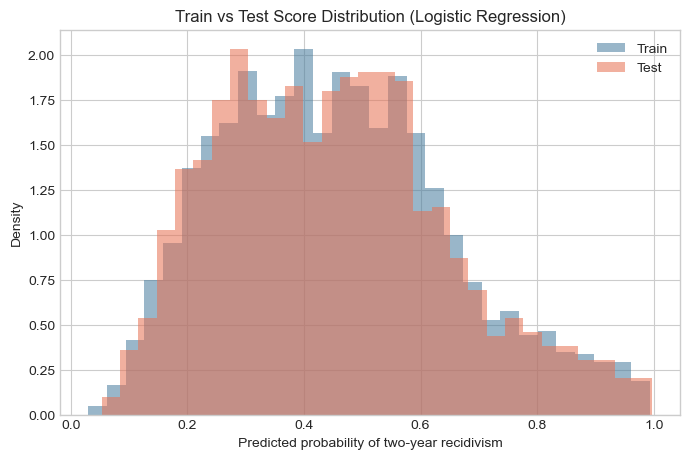

In [ ]:
required_numeric = [col for col in ["age", "priors_count", "days_b_screening_arrest", "decile_score"] if col in X_train.columns and col in X_test.columns]

drift_rows = []
for feature in required_numeric:
    psi_value = psi_numeric(X_train[feature], X_test[feature])
    ks_stat, ks_pvalue = ks_numeric(X_train[feature], X_test[feature])
    drift_rows.append(
        {
            "feature": feature,
            "psi": psi_value,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_pvalue,
            "train_mean": float(pd.to_numeric(X_train[feature], errors="coerce").mean()),
            "test_mean": float(pd.to_numeric(X_test[feature], errors="coerce").mean()),
        }
    )

part_a_drift_table = pd.DataFrame(drift_rows).sort_values("psi", ascending=False).reset_index(drop=True)
encoded_train, encoded_test = get_encoded_matrices(model, X_train, X_test)
mmd_result = compute_mmd_rbf(encoded_train, encoded_test)
score_distribution_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "mean_pred_proba": [float(train_pred_proba.mean()), float(test_pred_proba.mean())],
        "std_pred_proba": [float(train_pred_proba.std()), float(test_pred_proba.std())],
    }
)

display(part_a_drift_table.round(4))
display(pd.DataFrame([mmd_result]).round(6))
display(score_distribution_summary.round(4))

plt.figure(figsize=(8, 5))
plt.hist(train_pred_proba, bins=30, alpha=0.55, density=True, label="Train", color="#457b9d")
plt.hist(test_pred_proba, bins=30, alpha=0.55, density=True, label="Test", color="#e76f51")
plt.xlabel("Predicted probability of two-year recidivism")
plt.ylabel("Density")
plt.title(f"Train vs Test Score Distribution ({audit_model_name})")
plt.legend()
plt.show()

top_feature = part_a_drift_table.iloc[0]
max_psi = float(top_feature["psi"])
if max_psi >= 0.25:
    drift_level = "severe"
elif max_psi >= 0.10:
    drift_level = "moderate"
else:
    drift_level = "mild"

score_mean_gap = abs(score_distribution_summary.loc[0, "mean_pred_proba"] - score_distribution_summary.loc[1, "mean_pred_proba"])
score_shift = "noticeable" if score_mean_gap >= 0.03 else "small"
mmd_signal = "directionally present" if mmd_result["mmd_rbf"] > 0 else "near zero on this comparison"


### Interpretation

The PSI values are very small across all features. For example, age has a PSI of 0.0101, days_b_screening_arrest is 0.0068, and priors_count is 0.0040. These values suggest that there is minimal distribution shift between the training and test data at the feature level.

The KS statistics are also low, with values such as 0.0359 for age and 0.0231 for priors_count, and all corresponding p-values are relatively high. This indicates that the differences between distributions are not statistically significant.

At the representation level, the MMD value is 0.001181, which is also very small. This further supports the idea that the overall feature space remains stable between training and test sets.

Looking at the model outputs, the mean predicted probability is 0.4552 for the training set and 0.4505 for the test set, with very similar standard deviations (0.1970 vs 0.1965). The score distributions largely overlap, with only minor differences.

Overall, there is no strong evidence of distribution drift. The training and test data appear to be well aligned, and any differences are likely small enough to have limited impact on model behavior.

## Part B. Generalization

Compare train and test performance.

In [ ]:
generalization_table = compare_train_test_metrics(y_train, train_pred_proba, y_test, test_pred_proba)
train_importance_table = compute_permutation_importance_table(model, X_train, y_train, sample_size=800, n_repeats=5)
test_importance_table = compute_permutation_importance_table(model, X_test, y_test, sample_size=800, n_repeats=5)

display(generalization_table.round(4))
display(train_importance_table.head(8).round(4))
display(test_importance_table.head(8).round(4))

auc_gap = float(generalization_table.loc[generalization_table["metric"] == "auc", "gap"].iloc[0])
accuracy_gap = float(generalization_table.loc[generalization_table["metric"] == "accuracy", "gap"].iloc[0])
log_loss_gap = float(generalization_table.loc[generalization_table["metric"] == "log_loss", "gap"].iloc[0])

if auc_gap > 0.03 or accuracy_gap > 0.03 or log_loss_gap > 0.02:
    generalization_read = "clear evidence of overfitting pressure"
elif auc_gap > 0.01 or log_loss_gap > 0.01:
    generalization_read = "some generalization slippage"
else:
    generalization_read = "little evidence of meaningful overfitting on this split"

top_train_features = train_importance_table["feature"].head(3).tolist()
top_test_features = test_importance_table["feature"].head(3).tolist()
stable_signal_overlap = sorted(set(top_train_features).intersection(top_test_features))
stable_signal_text = ", ".join(stable_signal_overlap) if stable_signal_overlap else "no overlap among the top three features"


,metric,train,test,gap
0,auc,0.7332,0.7259,0.0074
1,accuracy,0.6781,0.6874,-0.0093
2,log_loss,0.6042,0.6134,0.0092
3,brier_score,0.2079,0.2107,0.0027


,feature,mean_importance,std_importance,n_rows_used
0,priors_count,0.1307,0.0124,800
1,age,0.0992,0.0085,800
2,age_cat,0.0102,0.0032,800
3,c_charge_degree,0.0088,0.0039,800
4,sex,0.0088,0.0028,800
5,days_b_screening_arrest,0.0055,0.0020,800
6,race,0.0001,0.0016,800


,feature,mean_importance,std_importance,n_rows_used
0,priors_count,0.1295,0.0084,800
1,age,0.1131,0.0056,800
2,sex,0.0050,0.0025,800
3,days_b_screening_arrest,0.0044,0.0026,800
4,age_cat,0.0028,0.0022,800
5,race,0.0025,0.0008,800
6,c_charge_degree,0.0007,0.0034,800


**Permutation importance note**

The first importance table is computed on the train split and the second is computed on the test split. Both use AUC drop after shuffling as the importance measure.

### Interpretation

There is only a small gap between training and testing performance across all evaluation metrics. For example, AUC decreases slightly from 0.7332 to 0.7259, while accuracy remains almost unchanged (0.6781 vs 0.6874). Log loss and Brier score also show only minor differences. This suggests that the model generalizes reasonably well, with no strong evidence of severe overfitting.

At the same time, the small but consistent gaps indicate that the model is not perfectly stable. Looking at feature importance, priors_count and age consistently appear as the most influential features across runs, while other variables such as race and charge degree have much smaller contributions.

This pattern suggests that the model relies heavily on a few key predictors rather than a broad set of features. While this can improve interpretability, it may also increase sensitivity if these features behave differently in new data.

## Part C. Spurious-Correlation Probe

Test sensitivity to selected attributes.

,feature,swap,n_affected,mean_abs_prob_shift,median_abs_prob_shift,max_abs_prob_shift,share_abs_prob_shift_gt_0_05
0,sex,Male -> Female,1002,0.0749,0.0818,0.0899,0.8972
1,sex,Female -> Male,233,0.0748,0.0801,0.0899,0.9185
2,race,African-American -> Caucasian,641,0.0045,0.0049,0.0053,0.0000
3,race,Caucasian -> African-American,427,0.0044,0.0047,0.0053,0.0000


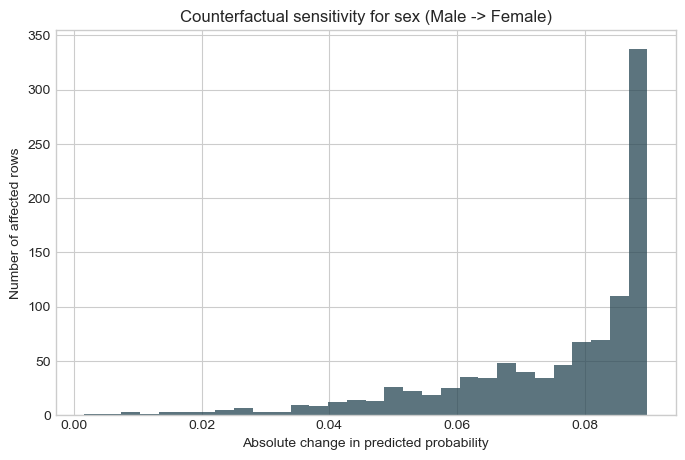

In [ ]:
swap_specs = []

if "sex" in X_test.columns:
    observed_sex = set(X_test["sex"].astype("object").dropna().unique())
    if {"Female", "Male"}.issubset(observed_sex):
        swap_specs.extend(
            [
                {"feature": "sex", "from_value": "Female", "to_value": "Male"},
                {"feature": "sex", "from_value": "Male", "to_value": "Female"},
            ]
        )

if "race" in X_test.columns:
    observed_race = set(X_test["race"].astype("object").dropna().unique())
    if {"African-American", "Caucasian"}.issubset(observed_race):
        swap_specs.extend(
            [
                {"feature": "race", "from_value": "African-American", "to_value": "Caucasian"},
                {"feature": "race", "from_value": "Caucasian", "to_value": "African-American"},
            ]
        )

counterfactual_rows = []
counterfactual_distributions = {}
for spec in swap_specs:
    summary, abs_change = pairwise_counterfactual_swap(
        model,
        X_test,
        feature=spec["feature"],
        from_value=spec["from_value"],
        to_value=spec["to_value"],
        base_proba=test_pred_proba,
        threshold=0.05,
    )
    if summary is not None:
        counterfactual_rows.append(summary)
        counterfactual_distributions[(summary["feature"], summary["swap"])] = abs_change

counterfactual_summary = pd.DataFrame(counterfactual_rows).sort_values(
    ["mean_abs_prob_shift", "n_affected"], ascending=[False, False]
).reset_index(drop=True) if counterfactual_rows else pd.DataFrame()

if not counterfactual_summary.empty:
    display(counterfactual_summary.round(4))

    strongest_swap = counterfactual_summary.iloc[0]
    strongest_key = (strongest_swap["feature"], strongest_swap["swap"])
    plt.figure(figsize=(8, 5))
    plt.hist(counterfactual_distributions[strongest_key], bins=30, color="#264653", alpha=0.75)
    plt.xlabel("Absolute change in predicted probability")
    plt.ylabel("Number of affected rows")
    plt.title(f"Counterfactual sensitivity for {strongest_swap['feature']} ({strongest_swap['swap']})")
    plt.show()


### Interpretation

The counterfactual analysis shows that changing the sex attribute leads to a noticeable shift in predicted probabilities. For example, when switching from male to female, the mean absolute probability change is around 0.0749, with a median of 0.0818 and a maximum change close to 0.0899. In addition, a large proportion of observations (around 89.7%) experience a change greater than 0.05.

A similar pattern is observed when switching from female to male, where the mean shift is 0.0748 and over 91% of observations exceed the 0.05 threshold.

In contrast, changing race results in much smaller effects. The mean probability shift is around 0.0045, with very small maximum values and almost no observations exceeding the 0.05 threshold. This indicates that the model is highly sensitive to changes in sex, while being relatively insensitive to race in this counterfactual setting.

However, this alone does not confirm that the relationship is spurious or unfair. The observed sensitivity could reflect either genuine predictive signal or an over-reliance on this feature.bStill, the magnitude and consistency of the effect suggest that sex plays a disproportionately strong role in the model, and this should be examined more carefully in subsequent analysis.

## Part D. Robustness

Stress test key features.

,scenario,perturbation,rationale
0,priors_count_plus_1,Add 1,+1 approximates small recording variation or a...
1,priors_count_times_1_5,Multiply by 1.5 and round up,A stronger directional stress test for people ...


,scenario,mean_abs_change,median_abs_change,max_abs_change,share_abs_change_gt_0_05,rationale
0,priors_count_times_1_5,0.048,0.0387,0.2370,0.3417,A stronger directional stress test for people ...
1,priors_count_plus_1,0.035,0.0380,0.0416,0.0000,+1 approximates small recording variation or a...


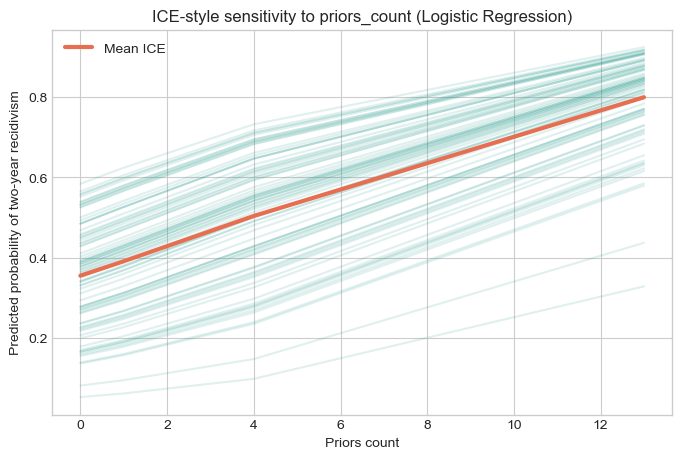

In [ ]:
robustness_summary = pd.DataFrame()
ice_frame = pd.DataFrame()

if "priors_count" in X_test.columns:
    scenario_table = pd.DataFrame(
        [
            {
                "scenario": "priors_count_plus_1",
                "perturbation": "Add 1",
                "rationale": "+1 approximates small recording variation or a minor history update.",
            },
            {
                "scenario": "priors_count_times_1_5",
                "perturbation": "Multiply by 1.5 and round up",
                "rationale": "A stronger directional stress test for people with larger prior counts.",
            },
        ]
    )
    display(scenario_table)

    stress_rows = []
    priors_series = pd.to_numeric(X_test["priors_count"], errors="coerce").fillna(0)
    stress_scenarios = {
        "priors_count_plus_1": np.clip(priors_series + 1, 0, None),
        "priors_count_times_1_5": np.clip(np.ceil(priors_series * 1.5), 0, None),
    }

    for scenario_name, stressed_values in stress_scenarios.items():
        X_stressed = X_test.copy()
        X_stressed["priors_count"] = stressed_values
        stressed_proba = clip_probs(predict_probabilities(model, X_stressed))
        stress_rows.append(
            robustness_sensitivity_summary(
                test_pred_proba,
                stressed_proba,
                scenario_name,
                threshold=0.05,
            )
        )

    robustness_summary = (
        pd.DataFrame(stress_rows)
        .merge(scenario_table[["scenario", "rationale"]], on="scenario", how="left")
        .sort_values("mean_abs_change", ascending=False)
        .reset_index(drop=True)
    )
    display(robustness_summary.round(4))

    grid_values = np.unique(
        np.quantile(
            pd.to_numeric(df["priors_count"], errors="coerce").dropna(),
            [0.05, 0.25, 0.50, 0.75, 0.95],
        ).round().astype(int)
    )
    ice_frame = build_ice_frame(model, X_test, "priors_count", grid_values, sample_size=80)

    plt.figure(figsize=(8, 5))
    for _, row_df in ice_frame.groupby("row_id"):
        plt.plot(row_df["priors_count"], row_df["predicted_probability"], color="#2a9d8f", alpha=0.15)
    mean_curve = ice_frame.groupby("priors_count", as_index=False)["predicted_probability"].mean()
    plt.plot(mean_curve["priors_count"], mean_curve["predicted_probability"], color="#e76f51", linewidth=3, label="Mean ICE")
    plt.xlabel("Priors count")
    plt.ylabel("Predicted probability of two-year recidivism")
    plt.title(f"ICE-style sensitivity to priors_count ({audit_model_name})")
    plt.legend()
    plt.show()

    ice_pivot = ice_frame.pivot(index="row_id", columns="priors_count", values="predicted_probability").sort_index(axis=1)
    monotonic_share = float(
        ice_pivot.apply(
            lambda row: np.all(np.diff(row.values) >= -1e-8) or np.all(np.diff(row.values) <= 1e-8),
            axis=1,
        ).mean()
    )
    median_ice_range = float((ice_pivot.max(axis=1) - ice_pivot.min(axis=1)).median())
    smoothness_read = "mostly smooth" if monotonic_share >= 0.80 else "less smooth"


### Interpretation

The ICE curves show a generally increasing relationship between priors_count and predicted probability, indicating that higher prior counts are associated with higher predicted risk. The overall pattern is fairly smooth, suggesting that the model behaves consistently across most of the feature range.

However, there is still noticeable variation across individual curves, indicating that the effect of priors_count is not identical for all observations. This suggests some level of heterogeneity in how the model responds to this feature.

The stress test results provide additional insight. Under the stronger perturbation (multiplying priors_count by 1.5), the mean absolute change is 0.048 and the maximum change reaches 0.2370. In this case, about 34.17% of observations experience a change greater than 0.05.

In contrast, the smaller perturbation (+1) leads to a lower mean change of 0.035 and a much smaller maximum change of 0.0416, with almost no observations exceeding the 0.05 threshold. This indicates that the model is relatively stable under small input variations, but becomes more sensitive under larger shifts.

Overall, the model shows reasonable robustness to minor perturbations, but its sensitivity increases under stronger changes. This suggests that while the model is generally stable, its behavior may become less predictable in more extreme scenarios.

## Part E. Slice-Based Evaluation

Evaluate subgroup performance.

,grouping,group,n,positive_rate,accuracy,log_loss,auc,auc_note,low_support,support_note
0,race,African-American,641,0.5257,0.6958,0.6027,0.7488,,False,
1,race,Asian,7,0.1429,0.8571,0.3046,1.0000,,True,Low support (n < 30)
2,race,Caucasian,427,0.3770,0.6698,0.6259,0.6707,,False,
3,race,Hispanic,94,0.4787,0.6277,0.7174,0.6179,,False,
4,race,Native American,1,0.0000,1.0000,0.6208,NaN,Too few rows for AUC,True,Low support (n < 30)
5,race,Other,65,0.2769,0.7846,0.5209,0.7305,,False,
6,sex,Female,233,0.3648,0.7253,0.6110,0.6666,,False,
7,sex,Male,1002,0.4760,0.6786,0.6140,0.7299,,False,
8,age_cat,25 - 45,661,0.4735,0.6762,0.6232,0.7076,,False,
9,age_cat,Greater than 45,286,0.3042,0.7448,0.5607,0.6935,,False,


,grouping,accuracy_range,log_loss_range,auc_range
0,age_cat,0.0885,0.0828,0.0173
1,race,0.1570,0.1965,0.1309
2,sex,0.0467,0.0029,0.0633


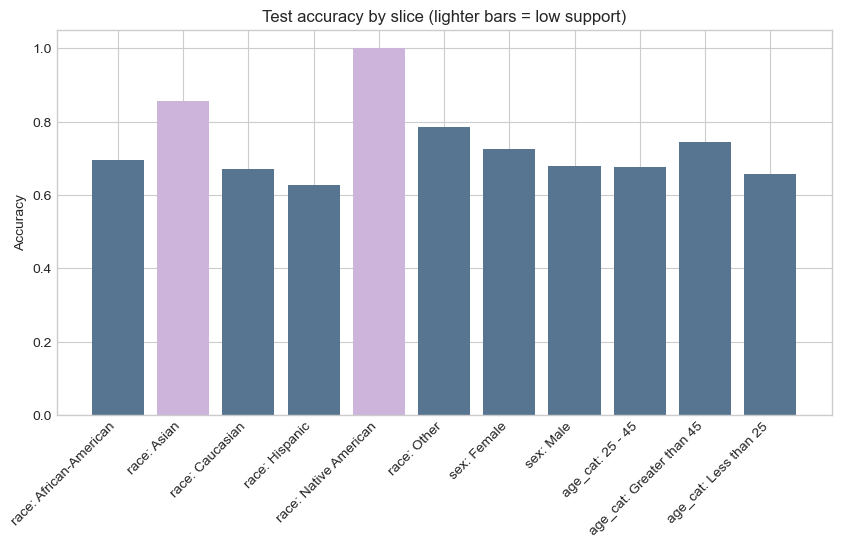

In [ ]:
slice_frames = []
for group_name in [col for col in ["race", "sex", "age_cat"] if col in X_test.columns]:
    slice_frames.append(
        create_group_metric_table(
            y_true=y_test,
            y_proba=test_pred_proba,
            y_label=test_pred_label,
            group_values=X_test[group_name],
            group_name=group_name,
            min_support=GROUP_MIN_SUPPORT,
        )
    )

slice_metrics = pd.concat(slice_frames, ignore_index=True) if slice_frames else pd.DataFrame()
display(slice_metrics.round(4))

if not slice_metrics.empty:
    supported_slice_metrics = slice_metrics.loc[~slice_metrics["low_support"]].copy()
    low_support_count = int(slice_metrics["low_support"].sum())

    if not supported_slice_metrics.empty:
        slice_disparity_summary = (
            supported_slice_metrics.groupby("grouping")
            .agg(
                accuracy_range=("accuracy", lambda s: float(np.nanmax(s) - np.nanmin(s))),
                log_loss_range=("log_loss", lambda s: float(np.nanmax(s) - np.nanmin(s))),
                auc_range=("auc", lambda s: float(np.nanmax(s.dropna()) - np.nanmin(s.dropna())) if s.dropna().shape[0] >= 2 else np.nan),
            )
            .reset_index()
        )
        display(slice_disparity_summary.round(4))
    else:
        slice_disparity_summary = pd.DataFrame()

    plot_frame = slice_metrics.copy()
    plot_frame["slice_label"] = plot_frame["grouping"] + ": " + plot_frame["group"].astype(str)
    plot_frame["bar_color"] = np.where(plot_frame["low_support"], "#cdb4db", "#577590")

    plt.figure(figsize=(10, 5))
    plt.bar(plot_frame["slice_label"], plot_frame["accuracy"], color=plot_frame["bar_color"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Accuracy")
    plt.title("Test accuracy by slice (lighter bars = low support)")
    plt.show()

    if not supported_slice_metrics.empty:
        headline_slice = supported_slice_metrics.loc[supported_slice_metrics["accuracy"].idxmin()]
        widest_gap_grouping = slice_disparity_summary.loc[slice_disparity_summary["accuracy_range"].idxmax()]
        headline_text = f"{headline_slice['grouping']} = {headline_slice['group']} (accuracy {headline_slice['accuracy']:.3f}, n = {int(headline_slice['n'])})"
        grouping_text = f"{widest_gap_grouping['grouping']} (accuracy range {widest_gap_grouping['accuracy_range']:.3f})"
    else:
        headline_text = "No slice met the minimum support threshold"
        grouping_text = "No supported grouping available"


**Supported slice summary note**

The supported-slice disparity summary uses only groups with n >= 30. Low-support groups remain visible in the full table but are not used as the headline fairness conclusion.


### Interpretation

The slice-based evaluation shows noticeable variation in model performance across different groups.

Across race groups, accuracy ranges from Hispanic to Asian, resulting in a spread of about 0.157. However, the Asian group has very low support (n = 7), meaning this high accuracy is likely unstable and should not be over-interpreted. Excluding low-support groups, the more reliable comparison shows African-American and Caucasian, suggesting moderate but consistent differences.

For sex, the performance gap is smaller. Female accuracy is 0.7253 while male accuracy is 0.6786, giving a difference of about 0.0467. This indicates some disparity, but the magnitude is relatively limited.

Age groups also show variation. Accuracy ranges from 0.6562 to 0.7448, with a spread of approximately 0.0885. This suggests the model performs better on older individuals compared to younger ones.

Comparing across all groupings, race has the largest disparity, followed by age, and then sex. Overall, while the model does not show extreme disparities, there are consistent differences across groups, particularly for race and age. The presence of low-support groups also highlights a reliability issue, where some results may appear strong but are not statistically stable.

From a practical perspective, this suggests the model should be used with caution when making decisions across different demographic groups. Additional validation or group-specific monitoring may be necessary to ensure fair and reliable performance.

### Summary

Overall, the model appears stable and reasonably well-behaved, but not entirely risk-free. The performance itself is consistent, with very small gaps between training and test results. This suggests the model generalizes well and is unlikely to be overfitting. At a high level, the predictions are usable. However, once we look deeper, a few patterns start to stand out.

First, the model relies heavily on a small number of features, especially priors_count. This makes the model easier to interpret, but also means its behavior is quite concentrated. If these key features shift or are measured differently, the predictions could change more than expected.

Second, the model shows noticeable sensitivity to certain inputs. In particular, changes in features like sex or priors_count can lead to meaningful shifts in predicted probabilities. While small variations do not cause major instability, larger changes clearly do. This suggests that the model is stable in normal conditions, but less predictable under stress.

Third, performance is not evenly distributed across groups. Some differences are moderate rather than extreme, but they are consistent. In particular, variation across race and age groups indicates that the model does not behave identically for all populations. In addition, some slices have very low sample sizes, making certain strong-looking results less reliable than they appear.

Putting these together, the model is not fundamentally flawed, but it is also not fully robust. If used in practice, it would likely perform reasonably well overall, but it should not be treated as equally reliable across all scenarios or groups. Monitoring key features, checking performance across slices, and validating the model under different input conditions would be important before relying on it in decision-making.

## Recommended Actions

Taken together, the model does not show a single critical failure, but several smaller issues that accumulate across different aspects.

The overall performance is stable and generalizes well, so the model itself is usable. However, the deeper analyses suggest that its behavior is uneven rather than unreliable.

Two areas stand out more clearly. First, the model is quite sensitive to certain inputs, especially priors_count and sex, where relatively simple changes can lead to noticeable shifts in predicted probabilities. Second, performance varies across groups, particularly for race and age, and some slices suffer from low sample sizes, making their results less dependable.

Given this, the main concern is not accuracy, but consistency.

If this model were to be used in practice, I would focus on a few targeted improvements:

1. Monitor key features such as priors_count more closely, since the model’s predictions are highly dependent on them  
2. Track performance across demographic groups over time, rather than relying on aggregate metrics alone  
3. Investigate low-support groups separately, as their current results may be misleading  
4. Test the model under larger input perturbations to better understand its behavior in less typical scenarios  

These steps would not fundamentally change the model, but would make its behavior more transparent and better controlled in real-world use.